In [354]:
import polars as pl
import matplotlib.pyplot as plt

In [355]:
df = pl.read_csv("AirPassengers.csv")
df

Month,#Passengers
str,i64
"""1949-01""",112
"""1949-02""",118
"""1949-03""",132
"""1949-04""",129
"""1949-05""",121
…,…
"""1960-08""",606
"""1960-09""",508
"""1960-10""",461


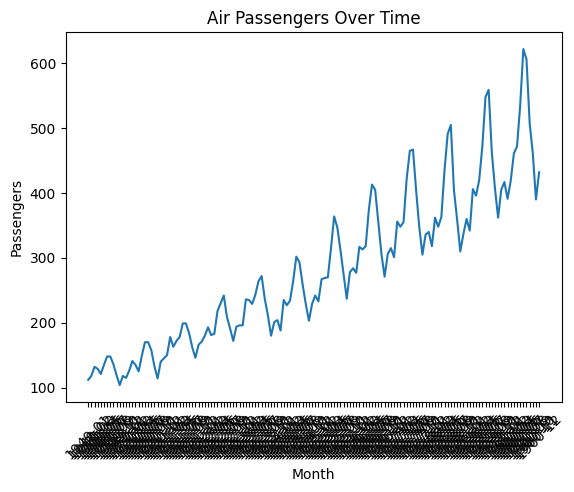

In [356]:
plt.plot(df["Month"], df["#Passengers"])
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.title("Air Passengers Over Time")
plt.xticks(rotation=45)
plt.show()

Из графика временного ряда уже видно наличие сезонности, которая проявляется в регулярных колебаниях количества пассажиров в течение года. Также можно заметить общую тенденцию роста количества пассажиров с течением времени.

## Проанализируем временной ряд на тренд и сезонность более строго


Скользящее среднее

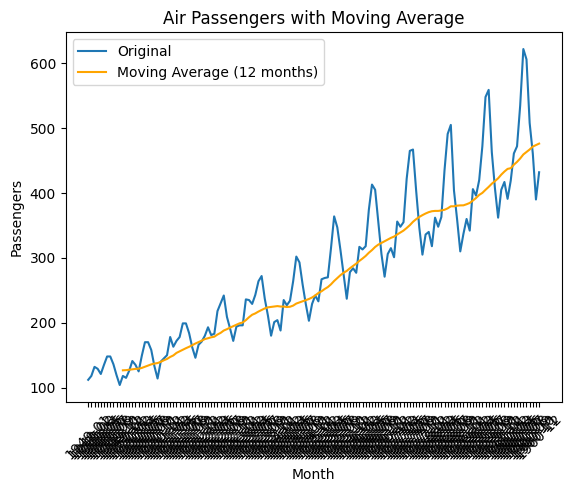

In [357]:
df = df.with_columns(
    pl.col("#Passengers").rolling_mean(window_size=12).alias("MA_12")
)
plt.plot(df["Month"], df["#Passengers"], label="Original")
plt.plot(df["Month"], df["MA_12"], label="Moving Average (12 months)", color="orange")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.title("Air Passengers with Moving Average")
plt.xticks(rotation=45)
plt.legend()
plt.show()

На графике виден явный возрастающий тренд

Определение сезонности с помощью автокорреляционной функции (ACF)

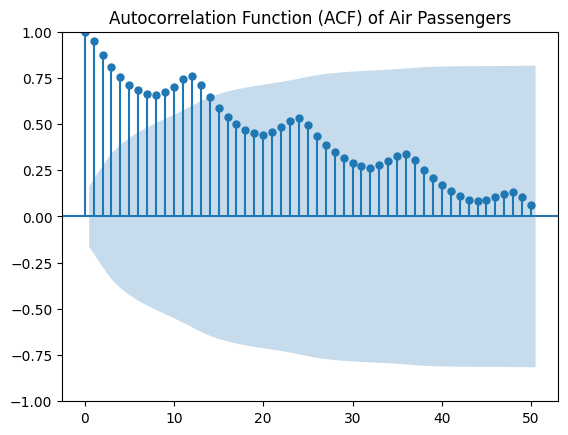

In [358]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df["#Passengers"], lags=50)
plt.title("Autocorrelation Function (ACF) of Air Passengers")
plt.show()

Мы видим, что ACF показывает значительные пики на лагах 12, 24, 36 и т.д., что указывает на наличие сезонности с периодом в 12 месяцев. Это подтверждает наши наблюдения с графика временного ряда.

Декомпозиция временного ряда с помощью встроенных методов

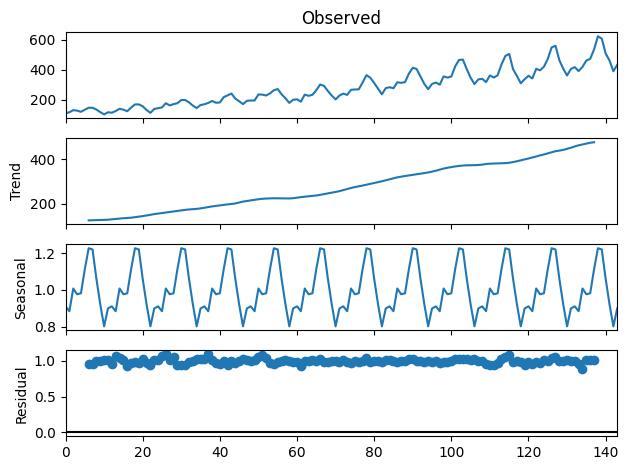

In [359]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['#Passengers'], model='multiplicative', period=12)
decomposition.plot()
None

Выводы все те же самые: видим общий рост количества пассажиров, а также сезонные колебания с периодом в 12 месяцев.

## Попытаем сделать ряд стационарным, убрав тренд и сезонность

In [360]:
import polars as pl
import numpy as np
from statsmodels.tsa.stattools import adfuller

df = df.with_columns([
    pl.col("#Passengers").log().alias("log_passengers")
]).with_columns([
    pl.col("log_passengers").diff(12).diff(1).alias("diff_log")
])

Логарифмируем

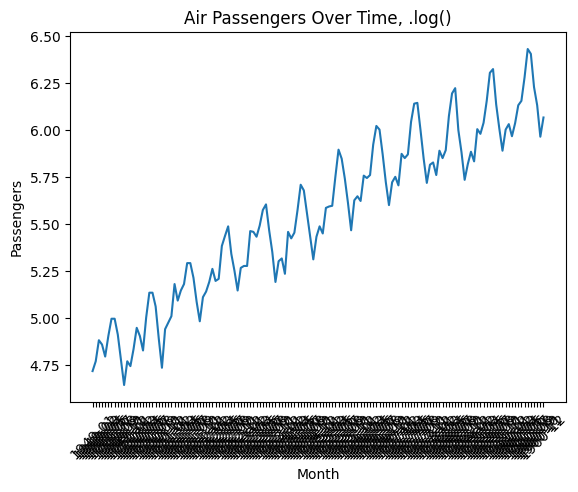

In [361]:
plt.plot(df["Month"], df["log_passengers"])
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.title("Air Passengers Over Time, .log()")
plt.xticks(rotation=45)
plt.show()

Дифференцируем

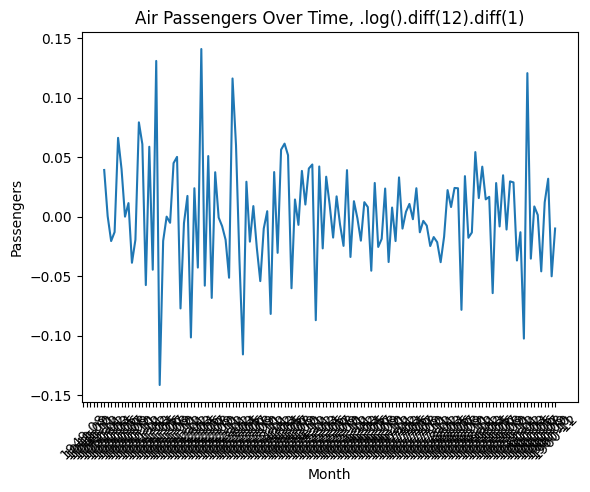

In [362]:
plt.plot(df["Month"], df["diff_log"])
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.title("Air Passengers Over Time, .log().diff(12).diff(1)")
plt.xticks(rotation=45)
plt.show()

In [363]:
stationary_data = df.select("diff_log").drop_nulls().to_series().to_numpy()

res = adfuller(stationary_data)
print(f"p-value: {res[1]}")
if res[0] > res[4]["5%"]:
    print("Ряд нестационарный")
else:
    print("Ряд стационарный")

p-value: 0.00024859123113841515
Ряд стационарный


In [364]:
df = df.with_columns(
    pl.col("Month").str.to_date("%Y-%m").alias("Month")
)

Извлечем признаки для регрессии

In [365]:
df = df.with_columns([
    pl.col("Month").dt.year().alias("year"),
    pl.col("Month").dt.month().alias("month"),
    pl.col("Month").dt.ordinal_day().alias("day_of_year")
])

month_period = 12
df = df.with_columns([
    (2 * np.pi * pl.col("month") / month_period).sin().alias("month_sin"),
    (2 * np.pi * pl.col("month") / month_period).cos().alias("month_cos"),
])

df = df.with_columns([
    pl.col("diff_log").shift(1).alias("lag_1"),
    pl.col("diff_log").shift(2).alias("lag_2"),
])
df = df.drop_nulls()

In [366]:
target = 'diff_log'
df

Month,#Passengers,MA_12,log_passengers,diff_log,year,month,day_of_year,month_sin,month_cos,lag_1,lag_2
date,i64,f64,f64,f64,i32,i8,i16,f64,f64,f64,f64
1950-04-01,135,128.833333,4.905275,-0.020496,1950,4,91,0.866025,-0.5,0.000361,0.039164
1950-05-01,125,129.166667,4.828314,-0.012939,1950,5,121,0.5,-0.866025,-0.020496,0.000361
1950-06-01,149,130.333333,5.003946,0.066148,1950,6,152,1.2246e-16,-1.0,-0.012939,-0.020496
1950-07-01,170,132.166667,5.135798,0.039915,1950,7,182,-0.5,-0.866025,0.066148,-0.012939
1950-08-01,170,134.0,5.135798,0.0,1950,8,213,-0.866025,-0.5,0.039915,0.066148
…,…,…,…,…,…,…,…,…,…,…,…
1960-08-01,606,463.333333,6.40688,-0.045934,1960,8,214,-0.866025,-0.5,0.001377,0.008563
1960-09-01,508,467.083333,6.230481,0.012024,1960,9,245,-1.0,-1.8370e-16,-0.045934,0.001377
1960-10-01,461,471.583333,6.133398,0.03183,1960,10,275,-0.866025,0.5,0.012024,-0.045934


In [367]:
train_size = int(len(df) * 0.8)

X_train = df[:train_size].select(pl.exclude(target))
Y_train = df[:train_size].select(target)

X_test = df[train_size:].select(pl.exclude(target))
Y_test = df[train_size:].select(target)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")


Train size: 103
Test size: 26


Попробуем линейную регрессию

In [368]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train.to_numpy(), Y_train.to_numpy().ravel())
Y_pred = model.predict(X_test.to_numpy())

Преобразуем логирфмированный и дифиеренцированный ряд в оригинальные измерения

In [ ]:
shift = 13

log_passengers_array = df["log_passengers"].to_numpy()
test_indices = np.arange(train_size, len(df))

Y_pred_log = (Y_pred 
              + log_passengers_array[test_indices - 1] 
              + log_passengers_array[test_indices - 12] 
              - log_passengers_array[test_indices - 13])

Y_test_log = (Y_test.to_numpy().ravel() 
              + log_passengers_array[test_indices - 1] 
              + log_passengers_array[test_indices - 12] 
              - log_passengers_array[test_indices - 13])

Y_pred_original = np.exp(Y_pred_log)
Y_test_original = np.exp(Y_test_log)

print(f"Y_pred_original shape: {Y_pred_original.shape}")
print(f"Y_test_original shape: {Y_test_original.shape}")

Y_pred_original shape: (26,)
Y_test_original shape: (26,)


In [370]:
Y_pred_original

array([303.4713414 , 338.52355453, 336.98633082, 321.52326233,
       386.81409003, 380.47996822, 407.59628973, 502.30575687,
       561.77356862, 576.11068828, 444.81155915, 397.78056288,
       340.09422476, 383.02534987, 415.54194728, 385.59435293,
       456.29465246, 417.49659887, 460.3327809 , 529.45736777,
       632.42161799, 639.8570627 , 497.94268947, 429.49548326,
       381.60233729, 427.59851314])

RMSE: 20.054063209887435


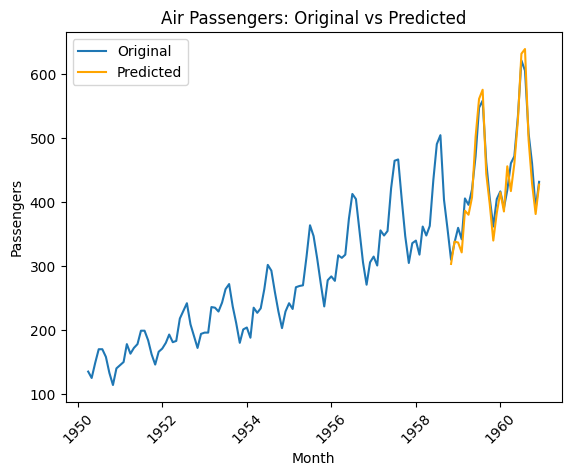

In [371]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge

rmse = np.sqrt(mean_squared_error(Y_test_original, Y_pred_original))
print(f"RMSE: {rmse}")

plt.plot(df["Month"], df["#Passengers"], label="Original")
plt.plot(df["Month"][train_size:], Y_pred_original, label="Predicted", color="orange")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.title("Air Passengers: Original vs Predicted")
plt.xticks(rotation=45)
plt.legend()
plt.show()

Воспользуемся алгоритмами SARIMA и Хольта-Уинтерса для предсказания количества пассажиров. Также построим наивную модель, которая будет предсказывать среднее значение.

In [372]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Для модели Хольта-Уинтерса надо использовать оригинальный ряд, а не дифференцированный, так как модель учитывает сезонность и тренд
Y_train_hw = df[:train_size].select("#Passengers").to_numpy().ravel()
model_hw = ExponentialSmoothing(Y_train_hw, trend='mul', seasonal='add', seasonal_periods=12).fit()
Y_pred_hw = model_hw.forecast(len(Y_test))

# В модель SARTIMA надо подавать log ряд
Y_train_sarima = df[:train_size].select("log_passengers").to_numpy().ravel()
model_sarima = SARIMAX(Y_train_sarima, order=(1,1,1), seasonal_order=(1,1,1,12)).fit()
Y_pred_sarima = np.exp(model_sarima.forecast(len(Y_test)))

Y_pred_sarima

c:\Users\Kolya\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


array([316.7958753 , 356.7296221 , 364.74450586, 347.65533108,
       402.24147453, 391.24349976, 401.53078472, 473.91267485,
       530.39823625, 533.90121849, 450.28016681, 394.74910437,
       347.46994139, 391.04080075, 399.75735584, 381.09340757,
       441.02151257, 429.03433708, 440.20208311, 519.43172461,
       581.26584194, 584.90963574, 493.70283675, 432.72601244,
       380.88356006, 428.64041206])

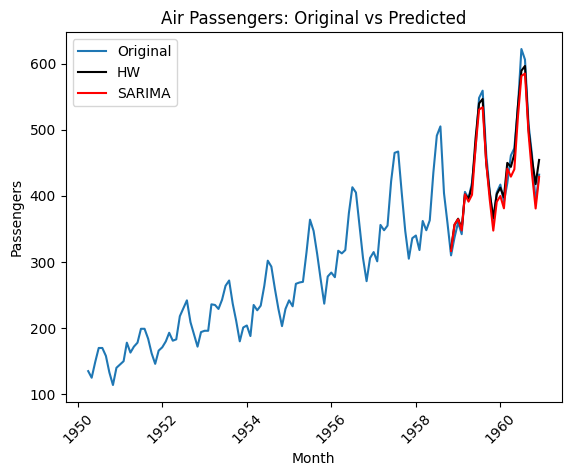

In [373]:
plt.plot(df["Month"], df["#Passengers"], label="Original")
plt.plot(df["Month"][train_size:], Y_pred_hw, label="HW", color="black")
plt.plot(df["Month"][train_size:], Y_pred_sarima, label="SARIMA", color="red")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.title("Air Passengers: Original vs Predicted")
plt.xticks(rotation=45)
plt.legend()
plt.show()

Наивная модель

In [374]:
naive_pred_diff = np.mean(Y_train.to_numpy())
Y_pred_naive_diff = np.full(len(Y_test), naive_pred_diff)

shift = 13
log_passengers_array = df["log_passengers"].to_numpy()
base_indices = np.arange(train_size, len(df)) - shift

# Отменяем diff(13) и log()
Y_pred_naive_log = log_passengers_array[base_indices] + Y_pred_naive_diff
Y_pred_naive = np.exp(Y_pred_naive_log)

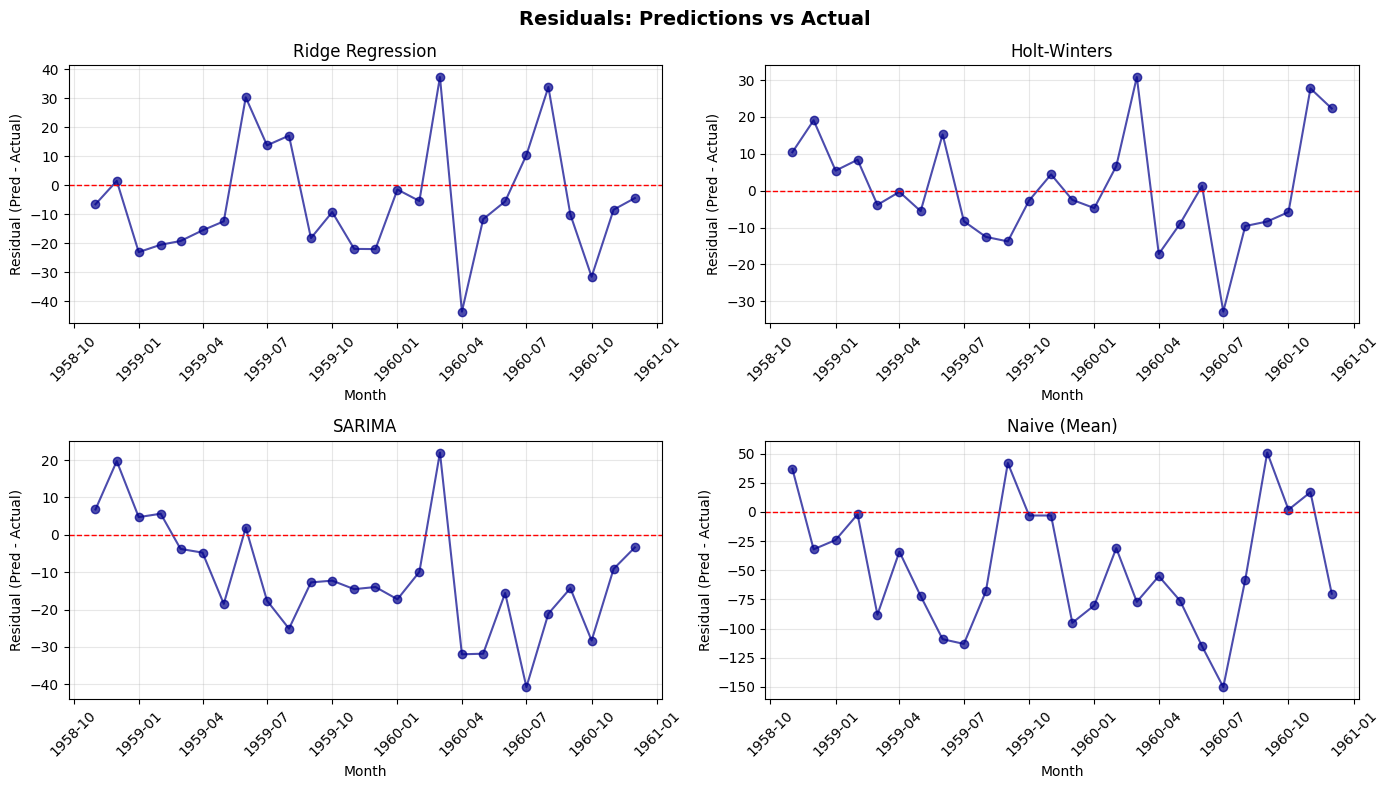


Статистика остатков
Ridge Regression     | Mean:    -5.62 | Std:    19.25 | Max Abs:    43.50
Holt-Winters         | Mean:     0.57 | Std:    14.18 | Max Abs:    32.82
SARIMA               | Mean:   -10.99 | Std:    14.87 | Max Abs:    40.73
Naive (Mean)         | Mean:   -46.51 | Std:    51.95 | Max Abs:   150.15


In [375]:

# График остатков (разности между предсказаниями и реальными данными)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Residuals: Predictions vs Actual', fontsize=14, fontweight='bold')

residuals = {
    'Ridge Regression': Y_pred_original - Y_test_original,
    'Holt-Winters': Y_pred_hw - Y_test_original,
    'SARIMA': Y_pred_sarima - Y_test_original,
    'Naive (Mean)': Y_pred_naive - Y_test_original
}


for ax, (model_name, residual) in zip(axes.flat, residuals.items()):
    ax.plot(df["Month"][train_size:], residual, marker='o', linestyle='-', alpha=0.7, color='darkblue')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel("Month")
    ax.set_ylabel("Residual (Pred - Actual)")
    ax.set_title(model_name)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Вывести статистику остатков
print("\n" + "=" * 60)
print("Статистика остатков")
print("=" * 60)
for model_name, residual in residuals.items():
    mean_residual = np.mean(residual)
    std_residual = np.std(residual)
    max_residual = np.max(np.abs(residual))
    print(f"{model_name:20} | Mean: {mean_residual:8.2f} | Std: {std_residual:8.2f} | Max Abs: {max_residual:8.2f}")
print("=" * 60)


In [ ]:
shift = 13

Y_pred_hw_train = model_hw.fittedvalues[shift:]
Y_pred_sarima_train = np.exp(model_sarima.fittedvalues)[shift:]

Y_train_actual = df[shift:train_size].select("#Passengers").to_numpy().ravel()
Y_pred_sarima_train[0] = Y_train_actual[0]

model_ridge = Ridge(alpha=0.01)
model_ridge.fit(X_train.to_numpy(), Y_train.to_numpy().ravel())

log_passengers_array = df["log_passengers"].to_numpy()
train_indices = np.arange(shift, train_size)

Y_train_pred_diff = model_ridge.predict(X_train.to_numpy()[shift:]).ravel()
Y_train_pred_log = (Y_train_pred_diff 
                    + log_passengers_array[train_indices - 1] 
                    + log_passengers_array[train_indices - 12] 
                    - log_passengers_array[train_indices - 13])
Y_train_ridge = np.exp(Y_train_pred_log)

Y_train_naive_diff_array = np.full(len(train_indices), naive_pred_diff)
Y_train_naive_log = (Y_train_naive_diff_array 
                     + log_passengers_array[train_indices - 1] 
                     + log_passengers_array[train_indices - 12] 
                     - log_passengers_array[train_indices - 13])
Y_train_naive = np.exp(Y_train_naive_log)

График с предсказаниями на тренировочном и тестовом наборах

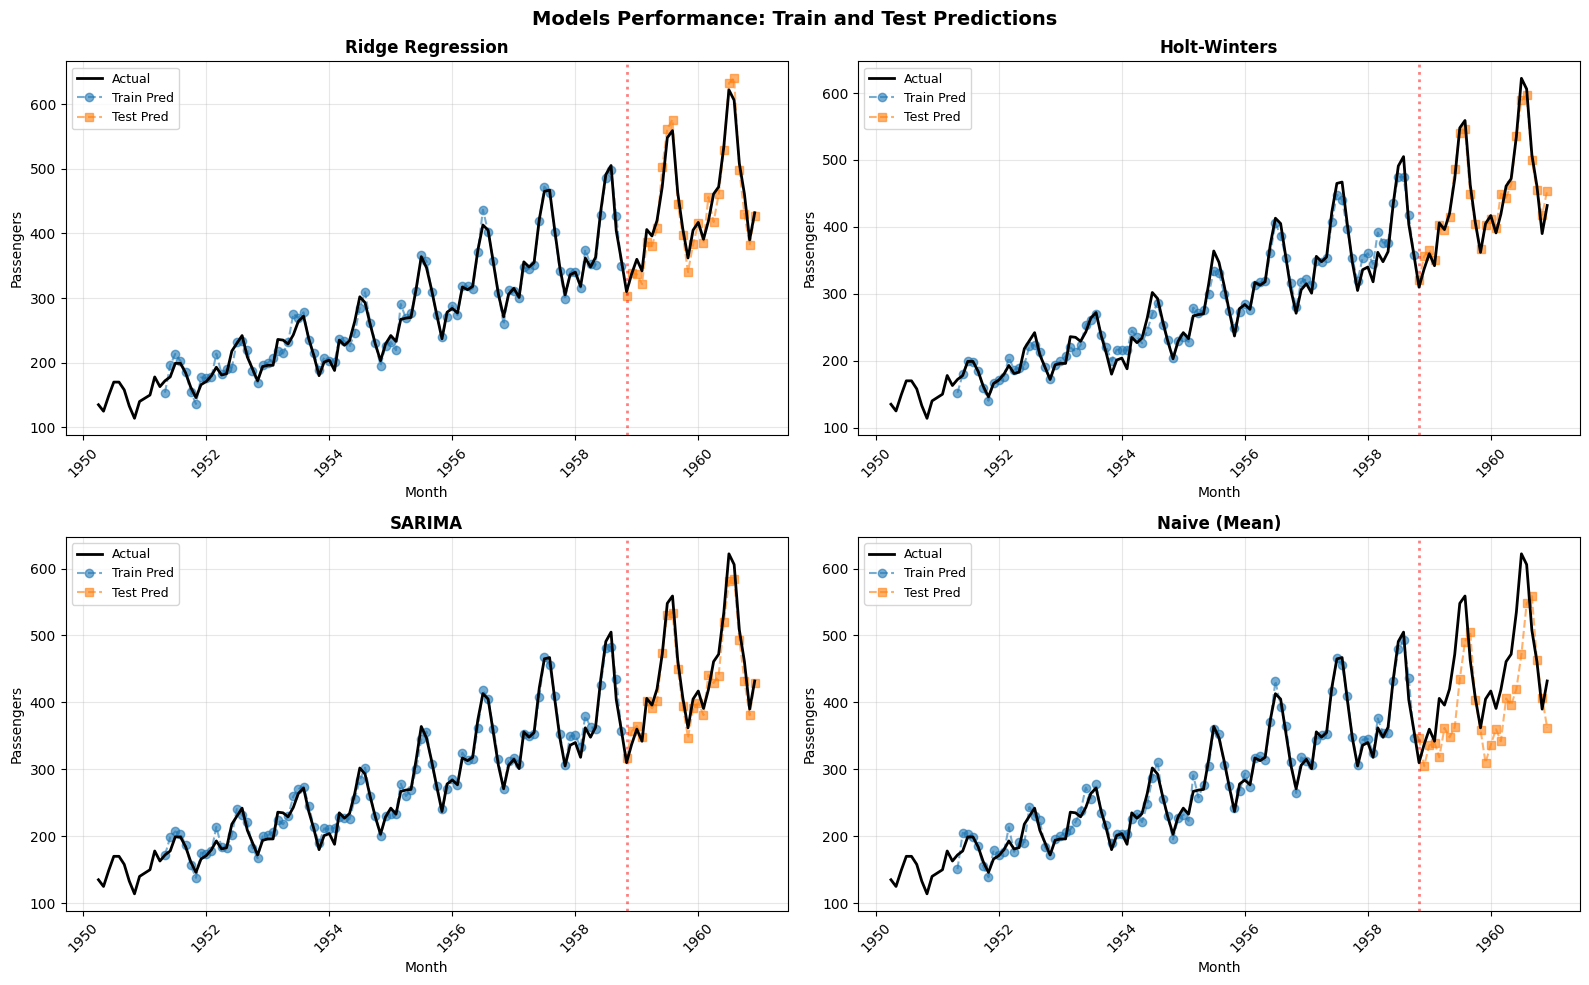

In [377]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Models Performance: Train and Test Predictions', fontsize=14, fontweight='bold')

train_months = df["Month"][shift:train_size].to_numpy()
test_months = df["Month"][train_size:].to_numpy()
all_months = df["Month"].to_numpy()
all_passengers = df["#Passengers"].to_numpy()

models_to_plot = [
    ('Ridge Regression', Y_train_ridge, Y_pred_original),
    ('Holt-Winters', Y_pred_hw_train, Y_pred_hw),
    ('SARIMA', Y_pred_sarima_train, Y_pred_sarima),
    ('Naive (Mean)', Y_train_naive, Y_pred_naive)
]

for ax, (model_name, train_pred, test_pred) in zip(axes.flat, models_to_plot):
    ax.plot(all_months, all_passengers, label='Actual', color='black', linewidth=2, zorder=5)
    ax.plot(train_months, train_pred, label='Train Pred', marker='o', linestyle='--', alpha=0.6)
    
    ax.plot(test_months, test_pred, label='Test Pred', marker='s', linestyle='--', alpha=0.6)
    ax.axvline(x=df["Month"][train_size], color='red', linestyle=':', linewidth=2, alpha=0.5)
    
    ax.set_xlabel("Month", fontsize=10)
    ax.set_ylabel("Passengers", fontsize=10)
    ax.set_title(model_name, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [378]:
Y_pred_naive

array([346.89234443, 304.90537478, 335.89575714, 339.89451615,
       317.90134158, 361.88769073, 347.89203418, 362.88738048,
       434.86504272, 490.84766891, 504.84332546, 403.87466037,
       358.88862147, 309.90382355, 336.89544689, 359.88831122,
       341.89389566, 405.87403987, 395.87714234, 419.86969642,
       471.8535636 , 547.82998486, 558.82657214, 462.85635582,
       406.87372963, 361.88769073])

In [379]:
print("=" * 85)
print("ДЕТАЛЬНЫЕ МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ")
print("=" * 85)

train_predictions = {
    'Ridge Regression': Y_train_ridge,
    'Holt-Winters': Y_pred_hw_train,
    'SARIMA': Y_pred_sarima_train,
    'Naive (Mean)': Y_train_naive
}

test_predictions = {
    'Ridge Regression': Y_pred_original,
    'Holt-Winters': Y_pred_hw,
    'SARIMA': Y_pred_sarima,
    'Naive (Mean)': Y_pred_naive
}

print("ТРЕНИРОВОЧНЫЙ НАБОР (80%)")
print("-" * 85)
print(f"{'Model':<20} {'RMSE':<15} {'MAE':<15} {'MAPE (%)':<15}")
print("-" * 85)

for model_name in train_predictions.keys():
    train_pred = train_predictions[model_name]
    rmse = np.sqrt(mean_squared_error(Y_train_actual, train_pred))
    mae = mean_absolute_error(Y_train_actual, train_pred)
    mape = np.mean(np.abs((Y_train_actual - train_pred) / Y_train_actual)) * 100
    print(f"{model_name:<20} {rmse:<15.2f} {mae:<15.2f} {mape:<15.2f}")

print()
print("ТЕСТОВЫЙ НАБОР (20%)")
print("-" * 85)
print(f"{'Model':<20} {'RMSE':<15} {'MAE':<15} {'MAPE (%)':<15}")
print("-" * 85)

for model_name in test_predictions.keys():
    test_pred = test_predictions[model_name]
    rmse = np.sqrt(mean_squared_error(Y_test_original, test_pred))
    mae = mean_absolute_error(Y_test_original, test_pred)
    mape = np.mean(np.abs((Y_test_original - test_pred) / Y_test_original)) * 100
    print(f"{model_name:<20} {rmse:<15.2f} {mae:<15.2f} {mape:<15.2f}")

ДЕТАЛЬНЫЕ МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ
ТРЕНИРОВОЧНЫЙ НАБОР (80%)
-------------------------------------------------------------------------------------
Model                RMSE            MAE             MAPE (%)       
-------------------------------------------------------------------------------------
Ridge Regression     10.10           7.54            3.04           
Holt-Winters         13.04           9.87            3.56           
SARIMA               10.00           7.74            2.95           
Naive (Mean)         11.35           8.87            3.48           

ТЕСТОВЫЙ НАБОР (20%)
-------------------------------------------------------------------------------------
Model                RMSE            MAE             MAPE (%)       
-------------------------------------------------------------------------------------
Ridge Regression     20.05           16.72           3.81           
Holt-Winters         14.19           11.11           2.54           
SARIMA               